# UChicago ADS RAG Pipeline — Full Analysis

End-to-end walkthrough of the current retrieval-augmented generation pipeline:

1. **Data Overview** — Chunk distribution, labels, text lengths
2. **Embedding & Indexing** — MiniLM embeddings, FAISS index, embedding space visualization
3. **Retrieval Pipeline Demo** — Step-by-step hybrid retrieval on sample queries
4. **Golden Test Set Evaluation** — Recall, MRR, NDCG on 55 manually-annotated queries
5. **Ablation Study** — Per-feature contribution measurement
6. **Error Analysis** — Failing queries and root causes

In [1]:
import json, math, os, sys
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

DATA_DIR = os.path.join(os.getcwd(), '..', 'data') if os.path.basename(os.getcwd()) == 'notebooks' else os.path.join(os.getcwd(), 'data')
sys.path.insert(0, os.path.join(DATA_DIR, '..'))

from retrieval import retrieve, rerank, tokenize_for_bm25, expand_query, RetrievalConfig

# Inline eval metrics (avoids importing eval.py which has heavy top-level imports)
def recall_at_k(retrieved_ids, relevant_ids, k):
    if not relevant_ids:
        return 0.0
    return sum(1 for rid in retrieved_ids[:k] if rid in relevant_ids) / len(relevant_ids)

def reciprocal_rank(retrieved_ids, relevant_ids):
    for i, rid in enumerate(retrieved_ids):
        if rid in relevant_ids:
            return 1.0 / (i + 1)
    return 0.0

def ndcg_at_k(retrieved_ids, relevant_ids, k):
    dcg = sum(1.0 / math.log2(i + 2) for i, rid in enumerate(retrieved_ids[:k]) if rid in relevant_ids)
    idcg = sum(1.0 / math.log2(i + 2) for i in range(min(len(relevant_ids), k)))
    return dcg / idcg if idcg > 0 else 0.0

_TRANSLATIONS = {
    "多少钱": "How much does the program cost?",
    "这个项目要读多久": "How long does the program take to complete?",
    "怎么申请": "How do I apply to the program?",
    "有奖学金吗": "Are there scholarships available?",
    "毕业后能找到什么工作": "What jobs can graduates find after the program?",
    "线上和线下有什么区别": "What is the difference between online and in-person programs?",
}
def translate_query(query):
    if all(ord(c) < 128 for c in query if not c.isspace()):
        return query
    return _TRANSLATIONS.get(query, query)

plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.facecolor'] = 'white'
print('Imports OK')

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


Imports OK


## 1. Data Overview

Load the deduplicated chunk corpus (1,012 chunks) and examine its structure.

In [2]:
with open(os.path.join(DATA_DIR, 'chunked_documents_dedup.json')) as f:
    chunks = json.load(f)

print(f'Total chunks: {len(chunks)}')
print(f'Fields per chunk: {list(chunks[0].keys())}')
print(f'Metadata fields: {list(chunks[0]["metadata"].keys())}')

Total chunks: 1012
Fields per chunk: ['text', 'metadata', 'chunk_id']
Metadata fields: ['chunk_type', 'heading', 'sub_heading', 'page_title', 'labels', 'level', 'source_urls']


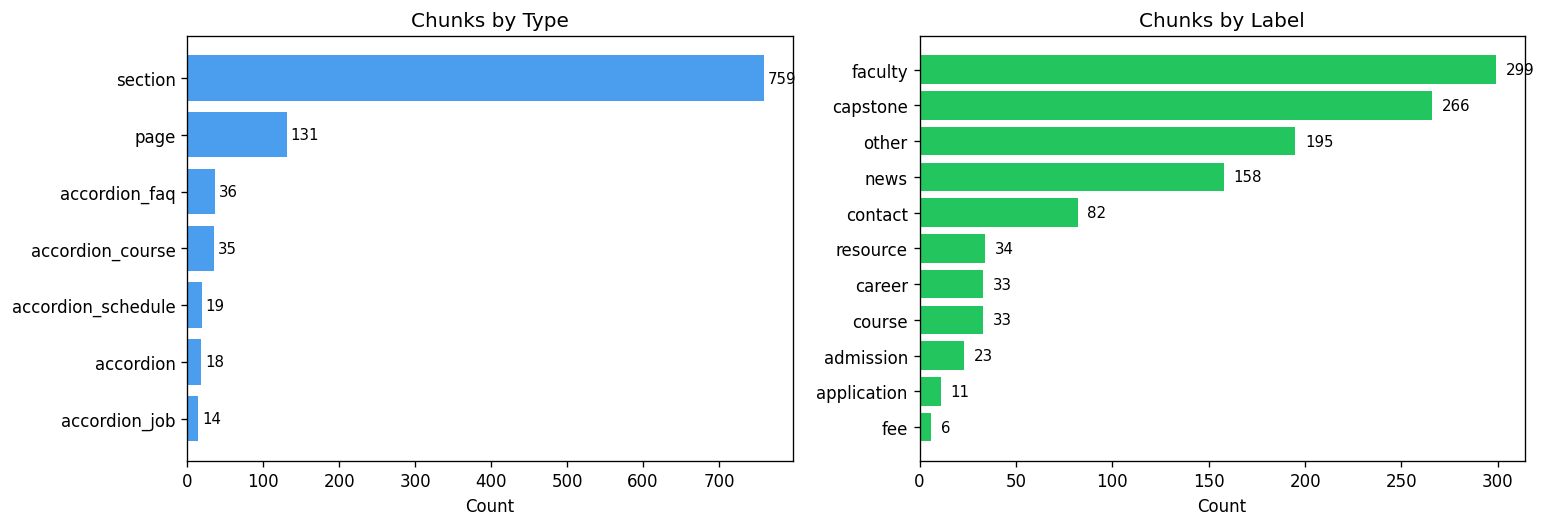

In [3]:
# Chunk type distribution
type_counts = Counter(c['metadata']['chunk_type'] for c in chunks)
types, counts = zip(*sorted(type_counts.items(), key=lambda x: -x[1]))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
bars = ax.barh(types[::-1], counts[::-1], color='#4a9eed')
ax.set_xlabel('Count')
ax.set_title('Chunks by Type')
for bar, v in zip(bars, counts[::-1]):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2, str(v), va='center', fontsize=9)

# Label frequency (a chunk can have multiple labels)
label_counts = Counter()
for c in chunks:
    for lbl in c['metadata'].get('labels', []):
        label_counts[lbl] += 1
labels, lcounts = zip(*sorted(label_counts.items(), key=lambda x: -x[1]))

ax = axes[1]
bars = ax.barh(labels[::-1], lcounts[::-1], color='#22c55e')
ax.set_xlabel('Count')
ax.set_title('Chunks by Label')
for bar, v in zip(bars, lcounts[::-1]):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2, str(v), va='center', fontsize=9)

plt.tight_layout()
plt.show()

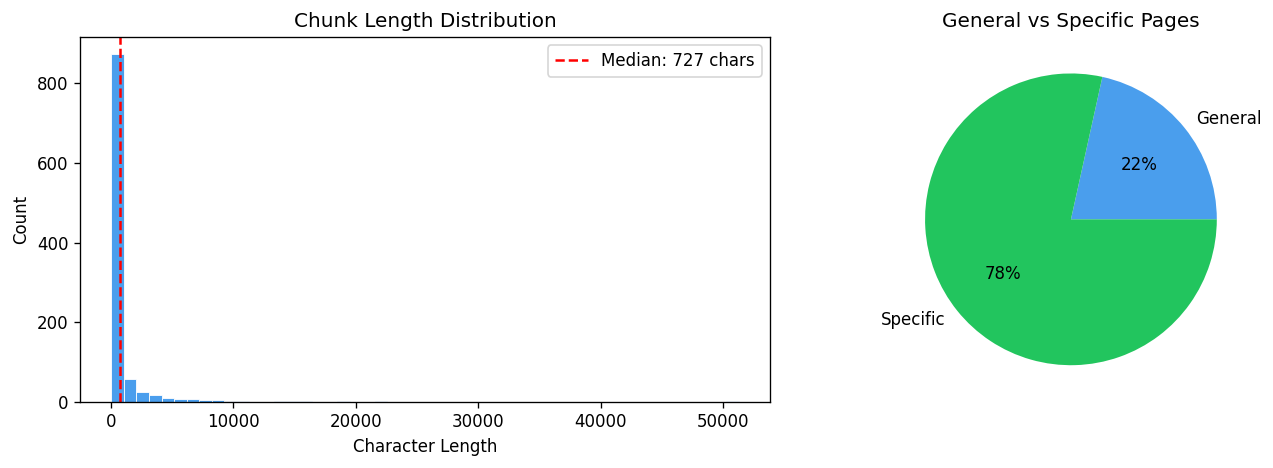

Length stats: min=51, max=51276, median=727, mean=1092


In [4]:
# Text length distribution and General vs Specific breakdown
lengths = [len(c['text']) for c in chunks]
level_counts = Counter(c['metadata'].get('level', 'unknown') for c in chunks)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.hist(lengths, bins=50, color='#4a9eed', edgecolor='white', linewidth=0.5)
ax.axvline(np.median(lengths), color='red', linestyle='--', label=f'Median: {int(np.median(lengths))} chars')
ax.set_xlabel('Character Length')
ax.set_ylabel('Count')
ax.set_title('Chunk Length Distribution')
ax.legend()

ax = axes[1]
lvls = list(level_counts.keys())
lvl_vals = [level_counts[l] for l in lvls]
ax.pie(lvl_vals, labels=lvls, autopct='%1.0f%%', colors=['#4a9eed', '#22c55e'])
ax.set_title('General vs Specific Pages')

plt.tight_layout()
plt.show()

print(f'Length stats: min={min(lengths)}, max={max(lengths)}, median={int(np.median(lengths))}, mean={int(np.mean(lengths))}')

## 2. Embedding & Indexing

Load pre-built MiniLM-L6-v2 embeddings (384-dim) and the FAISS inner-product index. Visualize the embedding space with PCA.

In [5]:
import faiss
from rank_bm25 import BM25Okapi
from sentence_transformers import SentenceTransformer, CrossEncoder

# Load resources
embeddings = np.load(os.path.join(DATA_DIR, 'embeddings_dedup.npy')).astype('float32')
faiss_index = faiss.read_index(os.path.join(DATA_DIR, 'uchicago_ads_faiss_dedup.index'))
embedder = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

tokenized = [tokenize_for_bm25(c['text']) for c in chunks]
bm25 = BM25Okapi(tokenized)

cross_enc = CrossEncoder('cross-encoder/ms-marco-MiniLM-L-6-v2')

print(f'Embeddings: {embeddings.shape}')
print(f'FAISS index: {faiss_index.ntotal} vectors')
print(f'BM25 index: {len(tokenized)} documents')

Embeddings: (1012, 384)
FAISS index: 1012 vectors
BM25 index: 1012 documents


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


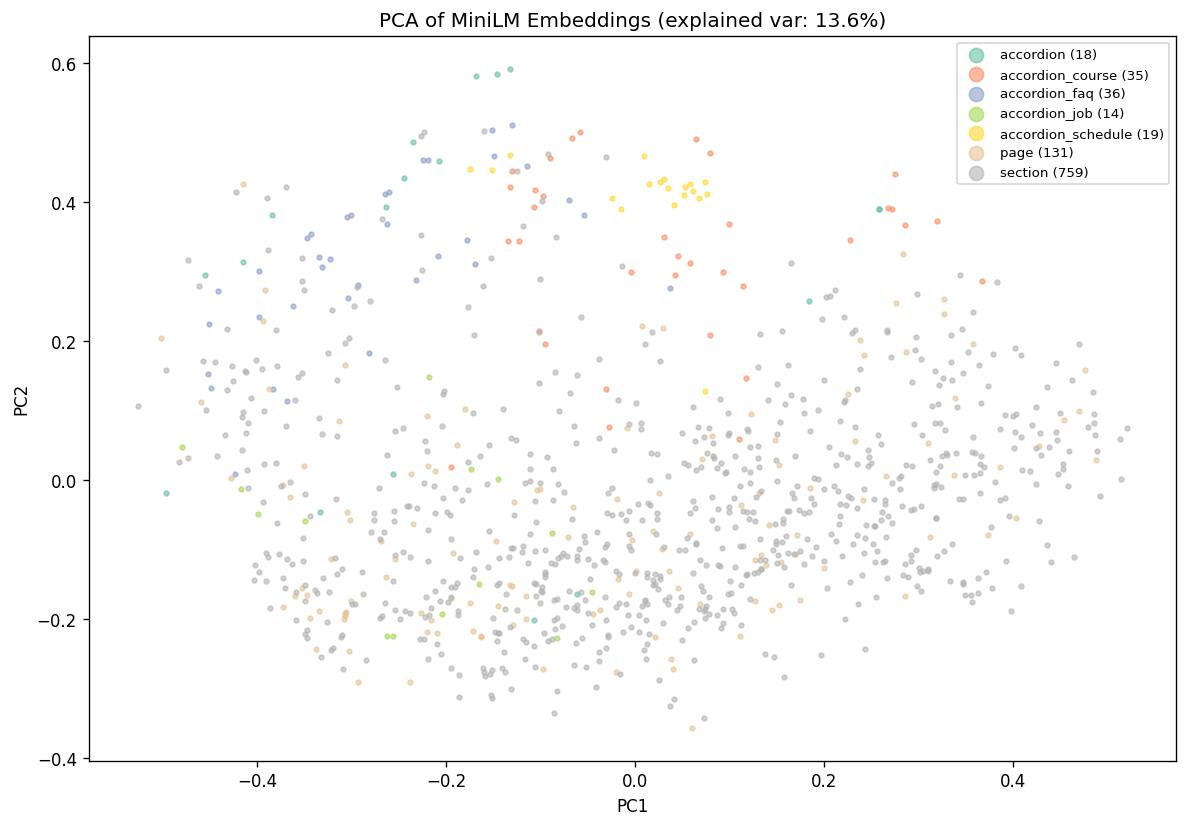

In [6]:
# PCA visualization of embedding space colored by chunk type
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(embeddings)

type_list = [c['metadata']['chunk_type'] for c in chunks]
uniq_types = sorted(set(type_list))
colors_map = plt.cm.Set2(np.linspace(0, 1, len(uniq_types)))
type_to_color = {t: colors_map[i] for i, t in enumerate(uniq_types)}

fig, ax = plt.subplots(figsize=(10, 7))
for t in uniq_types:
    mask = [i for i, tt in enumerate(type_list) if tt == t]
    ax.scatter(coords[mask, 0], coords[mask, 1], s=8, alpha=0.6,
              color=type_to_color[t], label=f'{t} ({len(mask)})')

ax.legend(fontsize=8, markerscale=3, loc='upper right')
ax.set_title(f'PCA of MiniLM Embeddings (explained var: {pca.explained_variance_ratio_.sum():.1%})')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
plt.tight_layout()
plt.show()

## 3. Retrieval Pipeline Demo

Walk through the hybrid retrieval process step-by-step on sample queries. Show what each stage (FAISS, BM25, RRF fusion, cross-encoder reranking) contributes.

In [7]:
def demo_retrieval(query, chunk_records, embedder, bm25, faiss_index, cross_enc, top_k=5):
    """Show step-by-step retrieval results for a single query."""
    print(f'Query: "{query}"')
    expanded = expand_query(query)
    if expanded != query:
        print(f'Synonym expansion: "{expanded}"')
    print()

    n_chunks = len(chunk_records)
    q_emb = embedder.encode([query], normalize_embeddings=True)[0].astype('float32')

    # FAISS only
    scores, idxs = faiss_index.search(q_emb.reshape(1, -1), top_k)
    print(f'--- FAISS Top-{top_k} (semantic) ---')
    for i, (idx, score) in enumerate(zip(idxs[0], scores[0])):
        title = chunk_records[idx]['metadata'].get('page_title', '')[:50]
        print(f'  {i+1}. [{chunk_records[idx]["chunk_id"][:40]}] score={score:.3f}  "{title}"')

    # BM25 only
    bm25_scores = bm25.get_scores(tokenize_for_bm25(expanded))
    bm25_top = np.argsort(-bm25_scores)[:top_k]
    print(f'\n--- BM25 Top-{top_k} (lexical) ---')
    for i, idx in enumerate(bm25_top):
        title = chunk_records[idx]['metadata'].get('page_title', '')[:50]
        print(f'  {i+1}. [{chunk_records[idx]["chunk_id"][:40]}] score={bm25_scores[idx]:.2f}  "{title}"')

    # Full hybrid pipeline
    candidates = retrieve(query, chunk_records, embedder, bm25, faiss_index, top_k=15)
    hits = rerank(query, candidates, cross_enc, top_k=top_k)
    print(f'\n--- Hybrid + Reranking Top-{top_k} (final) ---')
    for i, h in enumerate(hits):
        print(f'  {i+1}. [{h["chunk_id"][:40]}] "{h["page_title"][:50]}"')
    print()

In [8]:
demo_queries = [
    'What are the admission requirements?',
    'How much does the program cost?',
    'What courses are in the machine learning track?',
    'What jobs do graduates get after the program?',
]

for q in demo_queries:
    demo_retrieval(q, chunks, embedder, bm25, faiss_index, cross_enc)
    print('=' * 70 + '\n')

Query: "What are the admission requirements?"
Synonym expansion: "What are the admission requirements? application how to apply eligibility requirement application how to apply eligibility requirement"



--- FAISS Top-5 (semantic) ---
  1. [chunk_761_FAQs_|_DSI] score=0.636  "FAQs | DSI"
  2. [chunk_441_How_to_Apply_|_DSI] score=0.593  "How to Apply | DSI"
  3. [chunk_765_FAQs_|_DSI] score=0.556  "FAQs | DSI"
  4. [chunk_778_FAQs_|_DSI] score=0.553  "FAQs | DSI"
  5. [chunk_443_How_to_Apply_|_DSI] score=0.503  "How to Apply | DSI"

--- BM25 Top-5 (lexical) ---
  1. [chunk_441_How_to_Apply_|_DSI] score=30.70  "How to Apply | DSI"
  2. [chunk_436_How_to_Apply_|_DSI] score=29.79  "How to Apply | DSI"
  3. [chunk_753_FAQs_|_DSI] score=26.92  "FAQs | DSI"
  4. [chunk_435_How_to_Apply_|_DSI] score=26.82  "How to Apply | DSI"
  5. [chunk_746_FAQs_|_DSI] score=25.91  "FAQs | DSI"



--- Hybrid + Reranking Top-5 (final) ---
  1. [chunk_441_How_to_Apply_|_DSI] "How to Apply | DSI"
  2. [chunk_747_FAQs_|_DSI] "FAQs | DSI"
  3. [chunk_436_How_to_Apply_|_DSI] "How to Apply | DSI"
  4. [chunk_438_How_to_Apply_|_DSI] "How to Apply | DSI"
  5. [chunk_746_FAQs_|_DSI] "FAQs | DSI"


Query: "How much does the program cost?"
Synonym expansion: "How much does the program cost? tuition tuition"

--- FAISS Top-5 (semantic) ---
  1. [chunk_919_Tuition,_Fees,_&_Aid_|_DSI] score=0.544  "Tuition, Fees, & Aid | DSI"
  2. [chunk_918_Tuition,_Fees,_&_Aid_|_DSI] score=0.514  "Tuition, Fees, & Aid | DSI"
  3. [chunk_443_How_to_Apply_|_DSI] score=0.500  "How to Apply | DSI"
  4. [chunk_920_Tuition,_Fees,_&_Aid_|_DSI] score=0.484  "Tuition, Fees, & Aid | DSI"
  5. [chunk_479_In-Person_Program_|_DSI] score=0.445  "In-Person Program | DSI"

--- BM25 Top-5 (lexical) ---
  1. [chunk_919_Tuition,_Fees,_&_Aid_|_DSI] score=24.40  "Tuition, Fees, & Aid | DSI"
  2. [chunk_918_Tuition,_Fees,_&_Aid_

--- FAISS Top-5 (semantic) ---
  1. [chunk_456_In-Person_Program_|_DSI] score=0.613  "In-Person Program | DSI"
  2. [chunk_451_In-Person_Program_|_DSI] score=0.604  "In-Person Program | DSI"
  3. [chunk_494_Online_Program_|_DSI] score=0.574  "Online Program | DSI"
  4. [chunk_656_Course_Progressions_|_DSI] score=0.551  "Course Progressions | DSI"
  5. [chunk_1082_Should_You_Choose_MS_in_Data_] score=0.550  "Should You Choose MS in Data Science or MS in Appl"

--- BM25 Top-5 (lexical) ---
  1. [chunk_764_FAQs_|_DSI] score=11.81  "FAQs | DSI"
  2. [chunk_472_In-Person_Program_|_DSI] score=10.71  "In-Person Program | DSI"
  3. [chunk_785_FAQs_|_DSI] score=10.16  "FAQs | DSI"
  4. [chunk_650_Course_Progressions_|_DSI] score=9.79  "Course Progressions | DSI"
  5. [chunk_651_Course_Progressions_|_DSI] score=9.76  "Course Progressions | DSI"

--- Hybrid + Reranking Top-5 (final) ---
  1. [chunk_493_Online_Program_|_DSI] "Online Program | DSI"
  2. [chunk_455_In-Person_Program_|_DSI] "In-Perso


--- Hybrid + Reranking Top-5 (final) ---
  1. [chunk_520_Online_Program_|_DSI] "Online Program | DSI"
  2. [chunk_1021_Career_Outcomes_|_DSI] "Career Outcomes | DSI"
  3. [chunk_1019_Career_Outcomes_|_DSI] "Career Outcomes | DSI"
  4. [chunk_529_Online_Program_|_DSI] "Online Program | DSI"
  5. [chunk_485_In-Person_Program_|_DSI] "In-Person Program | DSI"




## 4. Golden Test Set Evaluation

Evaluate the full pipeline on 55 manually-annotated queries with labeled relevant chunks.

In [9]:
with open(os.path.join(DATA_DIR, 'golden_test_set.json')) as f:
    test_set = json.load(f)

print(f'Golden test set: {len(test_set)} queries')
print(f'Categories: {Counter(t["category"] for t in test_set)}')
print(f'Avg relevant chunks per query: {np.mean([len(t["relevant_chunk_ids"]) for t in test_set]):.1f}')

Golden test set: 55 queries
Categories: Counter({'course': 19, 'admission': 16, 'fee': 7, 'capstone': 6, 'career': 4, 'application': 2, 'contact': 1})
Avg relevant chunks per query: 2.4


In [10]:
# Run evaluation
k_values = [1, 3, 5, 10]
results = []

for item in test_set:
    query = item['query']
    retrieval_query = translate_query(query)
    relevant = set(item['relevant_chunk_ids'])
    category = item.get('category', 'unknown')

    candidates = retrieve(retrieval_query, chunks, embedder, bm25, faiss_index, top_k=20)
    hits = rerank(retrieval_query, candidates, cross_enc, top_k=10)
    retrieved_ids = [h['chunk_id'] for h in hits]

    row = {'query': query, 'category': category, 'retrieved': retrieved_ids, 'relevant': relevant}
    for k in k_values:
        row[f'recall@{k}'] = recall_at_k(retrieved_ids, relevant, k)
    row['mrr'] = reciprocal_rank(retrieved_ids, relevant)
    row['ndcg@10'] = ndcg_at_k(retrieved_ids, relevant, 10)
    results.append(row)

print('Evaluation complete.')

Evaluation complete.


In [11]:
# Aggregate metrics
avg_metrics = {}
for k in k_values:
    key = f'recall@{k}'
    avg_metrics[key] = np.mean([r[key] for r in results])
avg_metrics['mrr'] = np.mean([r['mrr'] for r in results])
avg_metrics['ndcg@10'] = np.mean([r['ndcg@10'] for r in results])

print('AGGREGATE RESULTS:')
for k, v in avg_metrics.items():
    print(f'  {k:>10}: {v:.3f}')

AGGREGATE RESULTS:
    recall@1: 0.507
    recall@3: 0.929
    recall@5: 0.944
   recall@10: 0.966
         mrr: 0.973
     ndcg@10: 0.950


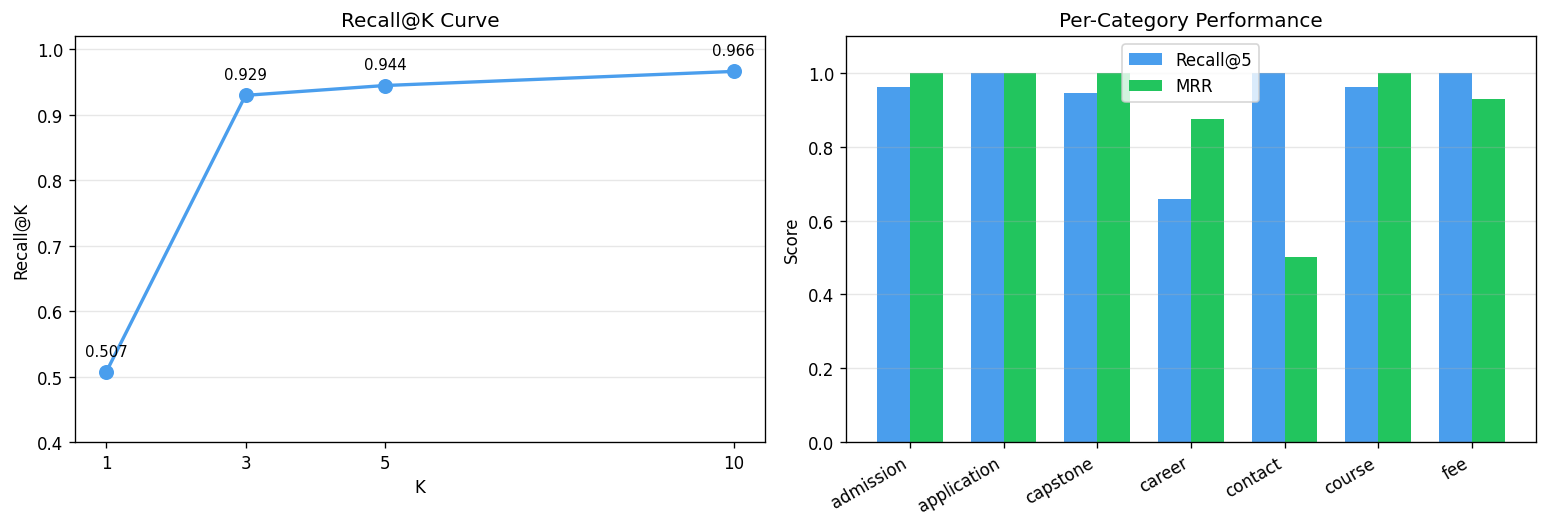

In [12]:
# Chart 1: Recall@K curve
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
k_scores = [avg_metrics[f'recall@{k}'] for k in k_values]
ax.plot(k_values, k_scores, 'o-', color='#4a9eed', linewidth=2, markersize=8)
for k, s in zip(k_values, k_scores):
    ax.annotate(f'{s:.3f}', (k, s), textcoords='offset points', xytext=(0, 10), ha='center', fontsize=9)
ax.set_xlabel('K')
ax.set_ylabel('Recall@K')
ax.set_title('Recall@K Curve')
ax.set_xticks(k_values)
ax.set_ylim(0.4, 1.02)
ax.grid(axis='y', alpha=0.3)

# Chart 2: Per-category Recall@5 and MRR
categories = sorted(set(r['category'] for r in results))
cat_r5 = [np.mean([r['recall@5'] for r in results if r['category'] == c]) for c in categories]
cat_mrr = [np.mean([r['mrr'] for r in results if r['category'] == c]) for c in categories]

ax = axes[1]
x = np.arange(len(categories))
w = 0.35
ax.bar(x - w/2, cat_r5, w, label='Recall@5', color='#4a9eed')
ax.bar(x + w/2, cat_mrr, w, label='MRR', color='#22c55e')
ax.set_xticks(x)
ax.set_xticklabels(categories, rotation=30, ha='right')
ax.set_ylabel('Score')
ax.set_title('Per-Category Performance')
ax.set_ylim(0, 1.1)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

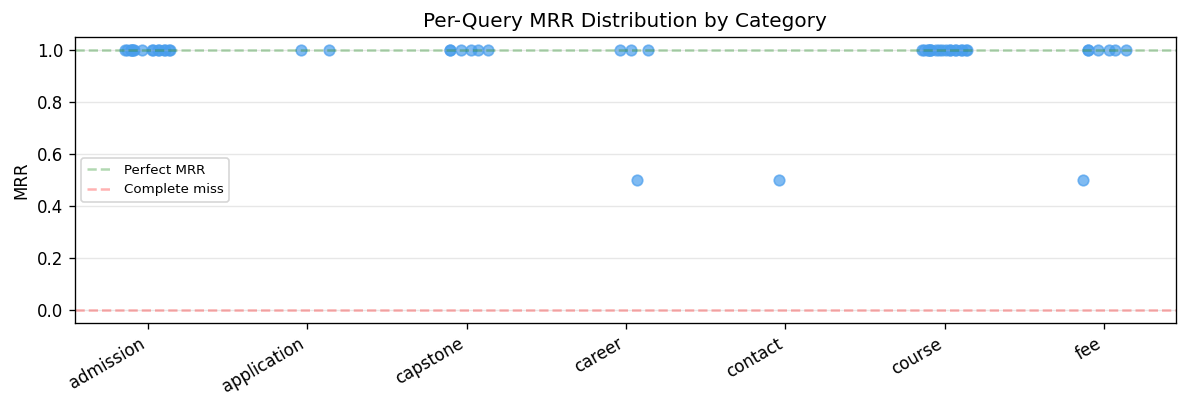

In [13]:
# Per-query MRR strip plot — show distribution and highlight failures
mrr_values = [r['mrr'] for r in results]
cat_list = [r['category'] for r in results]

fig, ax = plt.subplots(figsize=(10, 3.5))
for i, cat in enumerate(categories):
    cat_mrrs = [r['mrr'] for r in results if r['category'] == cat]
    jitter = np.random.RandomState(42).uniform(-0.15, 0.15, len(cat_mrrs))
    ax.scatter([i + j for j in jitter], cat_mrrs, s=40, alpha=0.7,
              color='#ef4444' if any(m == 0 for m in cat_mrrs) else '#4a9eed')

ax.set_xticks(range(len(categories)))
ax.set_xticklabels(categories, rotation=30, ha='right')
ax.set_ylabel('MRR')
ax.set_title('Per-Query MRR Distribution by Category')
ax.axhline(1.0, color='green', linestyle='--', alpha=0.3, label='Perfect MRR')
ax.axhline(0, color='red', linestyle='--', alpha=0.3, label='Complete miss')
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Ablation Study

Progressively enable pipeline features and measure the contribution of each. Each stage adds one component, evaluated on the same 55-query golden test set.

In [14]:
import faiss as faiss_mod
from rank_bm25 import BM25Okapi as BM25

def load_resources(dedup=False):
    """Load chunks, embedder, BM25, FAISS index, and cross-encoder."""
    suffix = '_dedup' if dedup else ''
    with open(os.path.join(DATA_DIR, f'chunked_documents{suffix}.json')) as f:
        cr = json.load(f)
    emb_path = os.path.join(DATA_DIR, f'embeddings{suffix}.npy')
    idx_path = os.path.join(DATA_DIR, f'uchicago_ads_faiss{suffix}.index')
    if os.path.exists(idx_path):
        fi = faiss_mod.read_index(idx_path)
    else:
        vecs = np.load(emb_path).astype('float32')
        norms = np.linalg.norm(vecs, axis=1, keepdims=True)
        norms[norms == 0] = 1
        vecs /= norms
        fi = faiss_mod.IndexFlatIP(vecs.shape[1])
        fi.add(vecs)
    tok = [tokenize_for_bm25(c['text']) for c in cr]
    bm = BM25(tok)
    return cr, embedder, bm, fi, cross_enc

STAGES = [
    ('1. FAISS only',
     False,
     RetrievalConfig(use_bm25=False, use_synonyms=False, use_heading_boost=False,
                     use_label_boost=False, use_url_penalty=False),
     False),
    ('2. + BM25 hybrid (RRF)',
     False,
     RetrievalConfig(use_bm25=True, use_synonyms=False, use_heading_boost=False,
                     use_label_boost=False, use_url_penalty=False),
     False),
    ('3. + Boosting + reranking',
     False,
     RetrievalConfig(),
     True),
    ('4. + Deduplication',
     True,
     RetrievalConfig(),
     True),
]

ablation_results = []
retrieve_k, rerank_k = 20, 10

for stage_name, dedup, config, use_reranking in STAGES:
    print(f'Running: {stage_name} (dedup={dedup}) ...', end=' ', flush=True)
    cr, emb, bm, fi, ce = load_resources(dedup=dedup)

    r5_list, mrr_list = [], []
    for item in test_set:
        query = translate_query(item['query'])
        relevant = set(item['relevant_chunk_ids'])
        candidates = retrieve(query, cr, emb, bm, fi, top_k=retrieve_k, config=config)
        if use_reranking:
            hits = rerank(query, candidates, ce, top_k=rerank_k)
        else:
            hits = candidates[:rerank_k]
        retrieved_ids = [h['chunk_id'] for h in hits]
        r5_list.append(recall_at_k(retrieved_ids, relevant, 5))
        mrr_list.append(reciprocal_rank(retrieved_ids, relevant))

    avg_r5 = np.mean(r5_list)
    avg_mrr = np.mean(mrr_list)
    ablation_results.append({'stage': stage_name, 'recall@5': avg_r5, 'mrr': avg_mrr})
    print(f'R@5={avg_r5:.3f}, MRR={avg_mrr:.3f}')

print('\nAblation complete.')

Running: 1. FAISS only (dedup=False) ... 

R@5=0.455, MRR=0.526
Running: 2. + BM25 hybrid (RRF) (dedup=False) ... 

R@5=0.528, MRR=0.624
Running: 3. + Boosting + reranking (dedup=False) ... 

R@5=0.663, MRR=0.755
Running: 4. + Deduplication (dedup=True) ... 

R@5=0.944, MRR=0.973

Ablation complete.


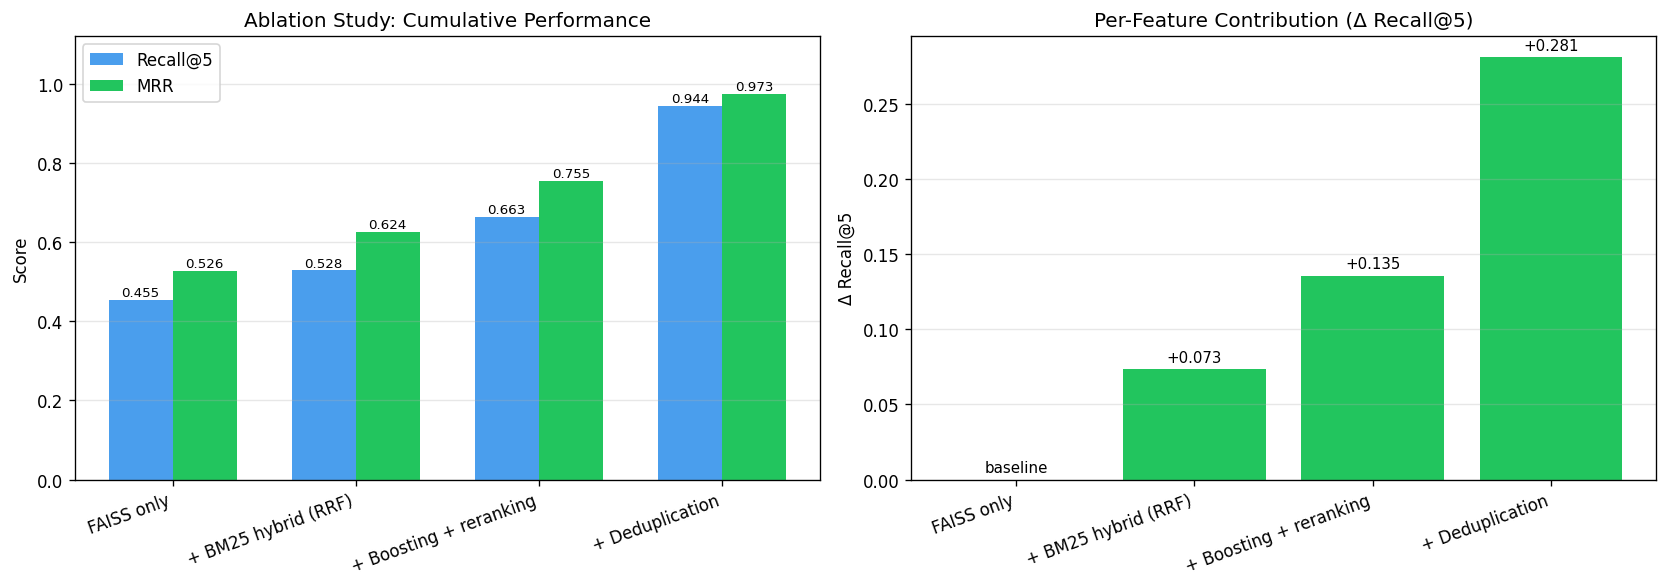

In [15]:
# Ablation: grouped bar chart + delta waterfall
stage_names = [r['stage'] for r in ablation_results]
r5_scores = [r['recall@5'] for r in ablation_results]
mrr_scores = [r['mrr'] for r in ablation_results]
deltas = [0] + [r5_scores[i] - r5_scores[i-1] for i in range(1, len(r5_scores))]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Grouped bar chart
ax = axes[0]
x = np.arange(len(stage_names))
w = 0.35
ax.bar(x - w/2, r5_scores, w, label='Recall@5', color='#4a9eed')
ax.bar(x + w/2, mrr_scores, w, label='MRR', color='#22c55e')
for i in range(len(stage_names)):
    ax.text(i - w/2, r5_scores[i] + 0.01, f'{r5_scores[i]:.3f}', ha='center', fontsize=8)
    ax.text(i + w/2, mrr_scores[i] + 0.01, f'{mrr_scores[i]:.3f}', ha='center', fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels([s.split('. ')[1] if '. ' in s else s for s in stage_names], rotation=20, ha='right')
ax.set_ylabel('Score')
ax.set_title('Ablation Study: Cumulative Performance')
ax.set_ylim(0, 1.12)
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Delta waterfall
ax = axes[1]
colors = ['#999999'] + ['#22c55e' if d > 0 else '#ef4444' for d in deltas[1:]]
ax.bar(range(len(stage_names)), deltas, color=colors)
for i, d in enumerate(deltas):
    label = f'+{d:.3f}' if d > 0 else ('baseline' if d == 0 else f'{d:.3f}')
    ax.text(i, d + 0.005, label, ha='center', fontsize=9)
ax.set_xticks(range(len(stage_names)))
ax.set_xticklabels([s.split('. ')[1] if '. ' in s else s for s in stage_names], rotation=20, ha='right')
ax.set_ylabel('\u0394 Recall@5')
ax.set_title('Per-Feature Contribution (\u0394 Recall@5)')
ax.axhline(0, color='black', linewidth=0.5)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Error Analysis

Examine the queries where the pipeline performs worst to understand failure modes.

In [16]:
# Find failing or weak queries
weak = sorted(results, key=lambda r: (r['recall@5'], r['mrr']))[:10]

print(f'Bottom 10 queries by Recall@5 + MRR:\n')
for r in weak:
    print(f'  [{r["category"]:>12}] R@5={r["recall@5"]:.2f}  MRR={r["mrr"]:.2f}  "{r["query"][:70]}"')
    # Show what was expected vs retrieved
    missed = r['relevant'] - set(r['retrieved'][:5])
    if missed:
        print(f'               Missed chunks: {[", ".join(list(missed)[:3])]}')
    print()

Bottom 10 queries by Recall@5 + MRR:

  [      career] R@5=0.33  MRR=0.50  "毕业后能找到什么工作"
               Missed chunks: ['chunk_1023_Career_Outcomes_|_DSI, chunk_1022_Career_Outcomes_|_DSI']

  [   admission] R@5=0.38  MRR=1.00  "What are the admission requirements for the program?"
               Missed chunks: ['chunk_443_How_to_Apply_|_DSI, chunk_439_How_to_Apply_|_DSI, chunk_437_How_to_Apply_|_DSI']

  [      career] R@5=0.50  MRR=1.00  "where do graduates work"
               Missed chunks: ['chunk_1022_Career_Outcomes_|_DSI']

  [      course] R@5=0.60  MRR=1.00  "What is the difference between the online and in-person programs?"
               Missed chunks: ['chunk_518_Online_Program_|_DSI, chunk_478_In-Person_Program_|_DSI']

  [      course] R@5=0.67  MRR=1.00  "What are the core courses in the MS in Applied Data Science program?"
               Missed chunks: ['chunk_452_In-Person_Program_|_DSI']

  [    capstone] R@5=0.67  MRR=1.00  "What are some examples of past capstone pr

In [17]:
# Detailed look at the worst query
worst = weak[0]
print(f'Query: "{worst["query"]}"')
print(f'Category: {worst["category"]}')
print(f'Recall@5: {worst["recall@5"]:.2f}, MRR: {worst["mrr"]:.2f}')
print(f'\nExpected {len(worst["relevant"])} relevant chunks:')
for cid in sorted(worst['relevant']):
    # Find the chunk text
    match = [c for c in chunks if c['chunk_id'] == cid]
    if match:
        print(f'  [{cid[:50]}]')
        print(f'    "{match[0]["text"][:120]}..."')

print(f'\nRetrieved top-5:')
for i, rid in enumerate(worst['retrieved'][:5]):
    match = [c for c in chunks if c['chunk_id'] == rid]
    status = 'HIT' if rid in worst['relevant'] else 'MISS'
    if match:
        print(f'  {i+1}. [{status}] [{rid[:50]}]')
        print(f'         "{match[0]["text"][:120]}..."')

Query: "毕业后能找到什么工作"
Category: career
Recall@5: 0.33, MRR: 0.50

Expected 3 relevant chunks:
  [chunk_1021_Career_Outcomes_|_DSI]
    "[Career Outcomes]
The career outcomes for our MS in Applied Data Science graduates are exceptional. Explore the diverse ..."
  [chunk_1022_Career_Outcomes_|_DSI]
    "Career Outcomes - Student Internships: The following companies have hired UChicago MS in Applied Data Science students a..."
  [chunk_1023_Career_Outcomes_|_DSI]
    "Career Outcomes - Alumni Careers: UChicago MS in Applied Data Science graduates work at the following companies: Goldman..."

Retrieved top-5:
  1. [MISS] [chunk_520_Online_Program_|_DSI]
         "[Online Program]
As a graduate of the online applied data science program, you will be a top competitor among data scien..."
  2. [HIT] [chunk_1021_Career_Outcomes_|_DSI]
         "[Career Outcomes]
The career outcomes for our MS in Applied Data Science graduates are exceptional. Explore the diverse ..."
  3. [MISS] [chunk_1019_Care

In [18]:
# Summary of failure modes
failure_cats = Counter(r['category'] for r in results if r['recall@5'] < 1.0)
total_cats = Counter(r['category'] for r in results)

print('Queries with imperfect Recall@5, by category:\n')
for cat in sorted(failure_cats.keys()):
    print(f'  {cat:>12}: {failure_cats[cat]}/{total_cats[cat]} queries have R@5 < 1.0')

print(f'\nOverall: {sum(1 for r in results if r["recall@5"] < 1.0)}/{len(results)} queries have R@5 < 1.0')
print(f'Queries with MRR = 0 (complete miss): {sum(1 for r in results if r["mrr"] == 0)}')

Queries with imperfect Recall@5, by category:

     admission: 1/16 queries have R@5 < 1.0
      capstone: 1/6 queries have R@5 < 1.0
        career: 3/4 queries have R@5 < 1.0
        course: 2/19 queries have R@5 < 1.0

Overall: 7/55 queries have R@5 < 1.0
Queries with MRR = 0 (complete miss): 0
